In [2]:
# Enable autoreload so edits to data_prep.py are picked up automatically
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add the parent folder (youtube-analytics/) to Python path
sys.path.append(str(Path.cwd().parent))

# Now you can import data_prep
from data_prep import load_country, get_cat_map

# Load US and Japan data
df_us = load_country('US')
df_jp = load_country('JP', encoding='latin-1')

DATA_DIR = Path.cwd().parent / "data"

us_cat_map = get_cat_map(DATA_DIR / "US_category_id.json")
jp_cat_map = get_cat_map(DATA_DIR / "JP_category_id.json")


In [3]:
# Load country data
df_us = load_country('US', encoding='utf-8')
df_jp = load_country('JP', encoding='latin-1')

# Map category IDs to human-readable names
df_us['category'] = df_us['category_id'].map(us_cat_map)
df_jp['category'] = df_jp['category_id'].map(jp_cat_map)

# Combine the datasets
import pandas as pd
df = pd.concat([df_us, df_jp], ignore_index=True)

In [ ]:
df['likes_norm'] = df.groupby('country')['likes'].transform(lambda x: x / x.max())
df['comments_norm'] = df.groupby('country')['comment_count'].transform(lambda x: x / x.max())
df['views_norm'] = df.groupby('country')['views'].transform(lambda x: x / x.max())

df['virality_score'] = (
    0.5 * df['likes_norm'] +
    0.3 * df['comments_norm'] +
    0.2 * df['views_norm']
)

<Axes: xlabel='engagement_rate', ylabel='category'>

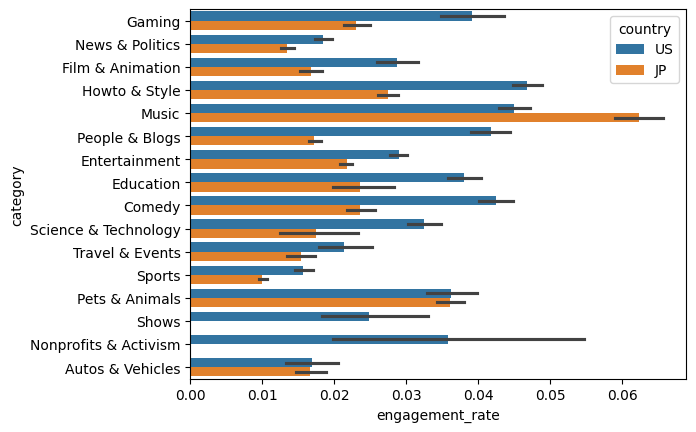

In [5]:
import seaborn as sns 
sns.barplot(
    data=df,
    x='engagement_rate',
    y='category',
    hue='country'
)

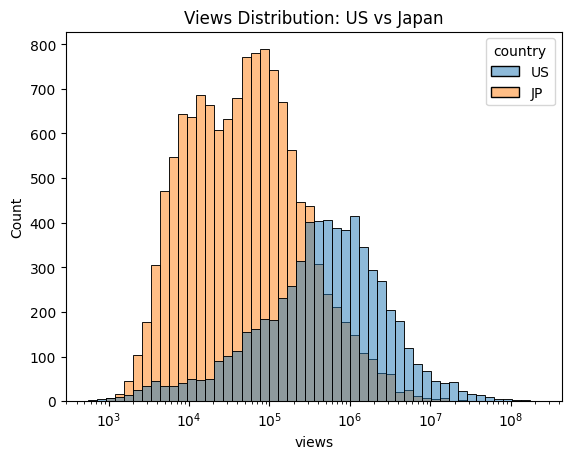

In [7]:
import matplotlib.pyplot as plt

sns.histplot(data=df, x='views', hue='country', log_scale=True, bins=50)
plt.title("Views Distribution: US vs Japan")
plt.show()

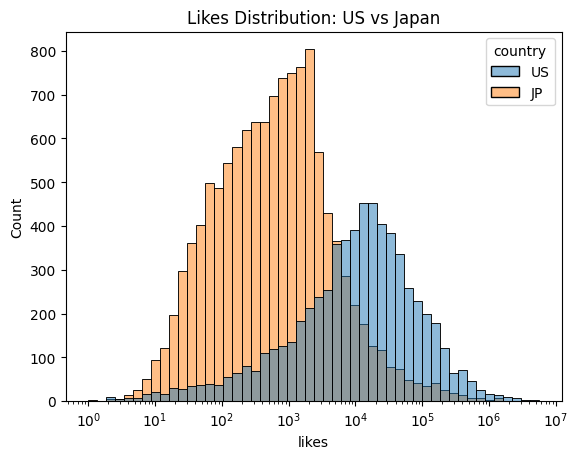

In [8]:
sns.histplot(data=df, x='likes', hue='country', bins=50, log_scale=True)
plt.title("Likes Distribution: US vs Japan")
plt.show()

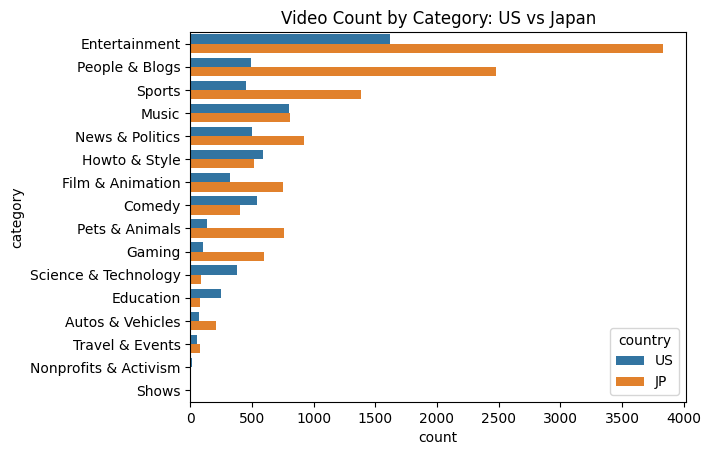

In [10]:
df['category'].value_counts()
sns.countplot(
    data=df,
    y='category',
    hue='country',
    order=df['category'].value_counts().index
)
plt.title("Video Count by Category: US vs Japan")
plt.show()

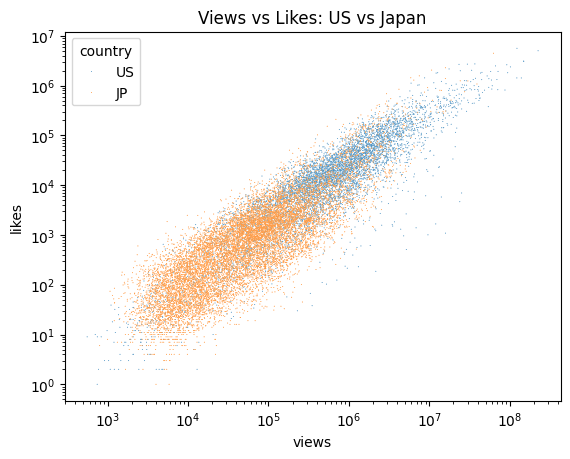

In [12]:
sns.scatterplot(data=df, x='views', y='likes', hue='country', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title("Views vs Likes: US vs Japan")
plt.show()

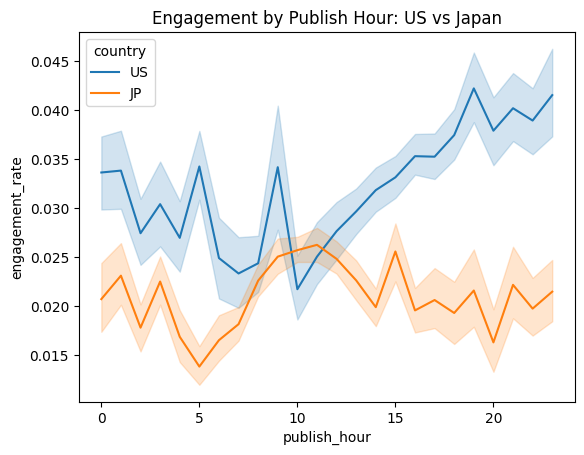

In [14]:
sns.lineplot(
    data=df,
    x='publish_hour',
    y='engagement_rate',
    hue='country'
)
plt.title("Engagement by Publish Hour: US vs Japan")
plt.show()